<a href="https://colab.research.google.com/github/iandrukhiv-cell/addressbook-python/blob/main/Module3Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Модуль 3. Аналітика часових рядів**

Часові ряди відрізняються від табличних даних тим, що кожне спостереження прив’язане до часу, а порядок точок є принциповим. У цьому модулі ми працюємо з історичними котируваннями металів платинової групи (джерело *PGM management*), щоб відпрацювати повний цикл: від завантаження та валідації часової осі до аналізу динаміки та побудови ознак (returns, rolling-метрики, індикатори).

Ключова ідея — перетворити “сирі” значення з джерела на **регулярний та надійний time-series датафрейм**: коректний `DatetimeIndex`, відсутність дублікатів дат, контроль частоти (daily), явна робота з пропусками. Далі ми виконуємо EDA, аналізуємо мінливість і режими, а потім будуємо ознаки, які роблять ряд придатним для прогнозування та порівняння між активами.

## План аналізу

1. Завантаження та підготовка.

2. Описовий аналіз (EDA).

3. Ознаки та індикатори.





# **Завантаження та підготовка часових рядів**

**Вступ.** Виконується робота над **часовими рядами** на прикладі історичних даних показників погоди та генерації електроенергії.

**Мета** — отримати **валідний time-series датафрейм**: правильно прочитати дані, привести типи, перевірити якість (індекс, дублікати, пропущені дні), зробити регулярну частоту та підготувати ряд до подальших кроків (EDA та побудови ознак), за потреби — виконати інфляційне коригування.

**План**
1. Завантаження даних у `DataFrame` та формування `DatetimeIndex`.
2. Приведення типів, сортування, усунення дублікатів і базова перевірка якості time-series.
3. Приведення до регулярної частоти (наприклад, daily) та обробка пропусків.
4. (Опційно) Коригування цін на інфляцію та збереження підготовленого ряду для наступних занять.

**Результат заняття:** підготовлений часовий ряд(и) у вигляді датафрейма(ів), готовий для описового аналізу та побудови ознак.



**Часові ряди** — це дані, впорядковані за часом, де кожне спостереження прив’язане до часової мітки (дата/час), а порядок і залежності між сусідніми моментами є суттєвими. На етапі **збору та агрегації** важливо зафіксувати часовий пояс, одиниці виміру й частоту, бо часто трапляються нерівномірні інтервали, пропуски дат і дублікати міток; під час агрегації потрібно правильно обрати операцію під зміст показника (для цін часто `last`, для обсягів `sum`, для вимірів `mean`), інакше спотворюється сигнал.

На етапі **попередньої обробки** ключове — привести дані до регулярної сітки (`asfreq`/`resample`), коректно обробити пропущені дати/значення (ffill, інтерполяція або пропуск залежно від процесу), часто застосовуючи log/returns і, для довгих періодів, коригування на інфляцію.

У **візуалізації та EDA** варто аналізувати не лише рівні, а й returns, ковзні середні та волатильність, сезонність/тренд (декомпозиція), кореляції тощо, бо характеристики ряду можуть змінюватися в часі.


In [ ]:
import os
import re
import json
import warnings
from pathlib import Path
from datetime import datetime, date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import requests

from pathlib import Path

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)   # або None — без обмеження
pd.set_option("display.width", 140)         # ширина рядка у символах
pd.set_option("display.max_colwidth", 50)   # ширина вмісту комірки (None — без обрізання)

# DATA_DIR = Path("./data_ts")
# DATA_DIR.mkdir(parents=True, exist_ok=True)

print("OK ✅  Environment ready")


OK ✅  Environment ready


## Опис даних

## Опис набору даних (Spain, hourly): споживання, генерація, ціни та погода

Це мультитабличний (2 файли) часовий ряд з погодинною частотою для енергоринку Іспанії. Дані охоплюють **4 роки** (≈ **35 064 годинні спостереження** за 2015–2018), включають **фактичні значення** та **прогнози (day-ahead) від оператора системи** — завдяки цьому можна напряму бенчмаркувати власні моделі проти “індустріального” прогнозу.

https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather

### Джерела

* **Consumption & generation**: ENTSO-E (публічний портал даних TSO). ([arXiv][1])
* **Settlement prices**: Red Eléctrica de España (REE).
* **Weather**: OpenWeather (історичні дані для 5 міст).


## Структура файлів і зв’язки

### 1) `energy_dataset.csv` (рівень: **1 рядок = 1 година по Іспанії**)

Ключ/час:

* **`time`** — часовий індекс.

Групи змінних

**A. Попит (load)**

* **`total load forecast`** — прогноз системного навантаження (day-ahead).
* **`total load actual`** — фактичне системне навантаження.

**B. Ціни**

* **`price day ahead`** — прогноз/ціна day-ahead (EUR/MWh).
* **`price actual`** — фактична/settlement ціна (EUR/MWh).

**C. Генерація за типами (MW)**

* `generation biomass`
* `generation fossil brown coal/lignite`
* `generation fossil coal-derived gas`
* `generation fossil gas`
* `generation fossil hard coal`
* `generation fossil oil`
* `generation fossil oil shale`
* `generation fossil peat`
* `generation geothermal`
* `generation hydro pumped storage aggregated`
* `generation hydro pumped storage consumption`
* `generation hydro run-of-river and poundage`
* `generation hydro water reservoir`
* `generation marine`
* `generation nuclear`
* `generation other`
* `generation other renewable`
* `generation solar`
* `generation waste`
* `generation wind offshore`
* `generation wind onshore`

**D. Прогнози генерації (day-ahead)**

* `forecast solar day ahead`
* `forecast wind onshore day ahead`
* **`forecast wind offshore ... day ahead`** — у датасеті інколи трапляється написання з помилкою на кшталт **`forecast wind offshore eday ahead`** (це варто врахувати при чистці назв).

### `weather_features.csv` (рівень: **1 рядок = 1 година × 1 місто**)

Ключі:

* **`dt_iso`** — datetime (локалізовано до CET у описах/похідних датадиктах).
* **`city_name`** — місто.

Міста (5 найбільших у наборі):

* `Valencia`, `Madrid`, `Bilbao`, **` Barcelona`** (з **початковим пробілом** у значенні!), `Seville`.

Основні метеоознаки (з одиницями):

* `temp`, `temp_min`, `temp_max` — температура (K)
* `pressure` — тиск (hPa)
* `humidity` — вологість (%)
* `wind_speed` — швидкість вітру (m/s)
* `wind_deg` — напрям (градуси)
* `rain_1h`, `rain_3h` — опади (mm)
* `snow_3h` — сніг (mm або еквівалент, як у джерелі)
* `clouds_all` — хмарність (%)

Категорійні/текстові поля погоди:

* `weather_id`, `weather_main`, `weather_description`, `weather_icon`.



## Завантаження даних


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nicholasjhana/energy-consumption-generation-prices-and-weather")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'energy-consumption-generation-prices-and-weather' dataset.
Path to dataset files: /kaggle/input/energy-consumption-generation-prices-and-weather


In [ ]:
import os
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/energy-consumption-generation-prices-and-weather/energy_dataset.csv
/kaggle/input/energy-consumption-generation-prices-and-weather/weather_features.csv


Завантаження даних з `csv` файлів з обробкою колонок тати та часу

In [ ]:
WEATHER_FEATURES_DATASET = path + "/weather_features.csv"
ENERGY_DATASET = path + "/energy_dataset.csv"

df_weather = pd.read_csv(WEATHER_FEATURES_DATASET, parse_dates=['dt_iso'])
df_energy = pd.read_csv(ENERGY_DATASET, parse_dates=['time'])

In [ ]:
df_energy

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,...,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,...,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,...,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,...,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,...,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,...,4861.0,21785.0,20264.0,38.41,56.04
...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 19:00:00+01:00,297.0,0.0,0.0,7634.0,...,3253.0,30619.0,30653.0,68.85,77.02
35060,2018-12-31 20:00:00+01:00,296.0,0.0,0.0,7241.0,...,3353.0,29932.0,29735.0,68.40,76.16
35061,2018-12-31 21:00:00+01:00,292.0,0.0,0.0,7025.0,...,3404.0,27903.0,28071.0,66.88,74.30
35062,2018-12-31 22:00:00+01:00,293.0,0.0,0.0,6562.0,...,3273.0,25450.0,25801.0,63.93,69.89


In [ ]:
df_weather

,dt_iso,city_name,temp,temp_min,temp_max,...,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,...,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,...,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,...,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,...,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,...,0,800,clear,sky is clear,01n
...,...,...,...,...,...,...,...,...,...,...,...
178391,2018-12-31 19:00:00+01:00,Seville,287.760,287.150,288.150,...,0,800,clear,sky is clear,01n
178392,2018-12-31 20:00:00+01:00,Seville,285.760,285.150,286.150,...,0,800,clear,sky is clear,01n
178393,2018-12-31 21:00:00+01:00,Seville,285.150,285.150,285.150,...,0,800,clear,sky is clear,01n
178394,2018-12-31 22:00:00+01:00,Seville,284.150,284.150,284.150,...,0,800,clear,sky is clear,01n


##Перевірка статистик, визначення неінформативних ознак

In [ ]:
# функції для виводу статистик датафрейма

##Видалення ознак

Видаляються ознак, у яких відсутні значення або дорівнюють нулю статистики:
* 'generation fossil coal-derived gas',
* 'generation fossil oil shale',
* 'generation fossil peat',
* 'generation geothermal',
* 'generation hydro pumped storage aggregated',
* 'generation marine',
* 'generation wind offshore',
* 'total load forecast',

а також колонки з прогнозами:
* 'forecast solar day ahead',
* 'forecast wind offshore eday ahead',
* 'forecast wind onshore day ahead',



In [ ]:
# видалення необхідних ознак

##Типи даних. Перетворення дати, часу


In [ ]:
# приведення відповідних колонок до формату дати-часу засобами to_datetime

##Пропуски та дублікати даних

In [ ]:
# функції визначення пропусків та дублікатів даних

In [ ]:
rep_energy  = missing_duplicates_report(df_energy,  name="df_energy",  subset_for_row_dups=None)
rep_weather = missing_duplicates_report(df_weather, name="df_weather", subset_for_row_dups=None)


##Виявлення викидів даних



In [ ]:
# функція визначення кількості викидів та оцінки outlier_rate

In [ ]:
display(outlier_report_iqr(df_energy, top=20))

In [ ]:
display(outlier_report_iqr(df_weather, top=20))

Частка викидів в обох наборах даних складає від 2% до 10%. Така частка може пояснюватись природніми випадками піків у електромережі та погодними аномаліями. Отже, ці значиння має сенс зберегти та використовувати у подальшій обробці.

##Групування даних

Визначення міст у наборі погодних даних

In [ ]:
# код визначення унікальних міст в наборі даних

In [ ]:
# групування даних погоди за виділеними містами

##Об'єднання таблиць даних

In [ ]:
# код об'єднання таблиць

In [ ]:
df_final

,index,time,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual,index_Barcelona,temp_Barcelona,temp_min_Barcelona,temp_max_Barcelona,pressure_Barcelona,humidity_Barcelona,wind_speed_Barcelona,wind_deg_Barcelona,rain_1h_Barcelona,rain_3h_Barcelona,snow_3h_Barcelona,clouds_all_Barcelona,index_Bilbao,temp_Bilbao,temp_min_Bilbao,temp_max_Bilbao,pressure_Bilbao,humidity_Bilbao,wind_speed_Bilbao,wind_deg_Bilbao,rain_1h_Bilbao,rain_3h_Bilbao,snow_3h_Bilbao,clouds_all_Bilbao,index_Madrid,temp_Madrid,temp_min_Madrid,temp_max_Madrid,pressure_Madrid,humidity_Madrid,wind_speed_Madrid,wind_deg_Madrid,rain_1h_Madrid,rain_3h_Madrid,snow_3h_Madrid,clouds_all_Madrid,index_Seville,temp_Seville,temp_min_Seville,temp_max_Seville,pressure_Seville,humidity_Seville,wind_speed_Seville,wind_deg_Seville,rain_1h_Seville,rain_3h_Seville,snow_3h_Seville,clouds_all_Seville,index_Valencia,temp_Valencia,temp_min_Valencia,temp_max_Valencia,pressure_Valencia,humidity_Valencia,wind_speed_Valencia,wind_deg_Valencia,rain_1h_Valencia,rain_3h_Valencia,snow_3h_Valencia,clouds_all_Valencia
0,0,2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,25385.0,50.10,65.41,107363,281.625,281.625,281.625,1035,100,7,58,0.0,0.0,0.0,0,71412,269.657312,269.657312,269.657312,1036,97,0,226,0.0,0.0,0.0,0,35145,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,142839,273.375,273.375,273.375,1039,75,1,21,0.0,0.0,0.0,0,0,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0
1,1,2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,24382.0,48.10,64.92,107364,281.625,281.625,281.625,1035,100,7,58,0.0,0.0,0.0,0,71413,269.763500,269.763500,269.763500,1035,97,0,229,0.0,0.0,0.0,0,35146,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,142840,273.375,273.375,273.375,1039,75,1,21,0.0,0.0,0.0,0,1,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0
2,2,2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,22734.0,47.33,64.48,107365,281.286,281.286,281.286,1036,100,7,48,0.0,0.0,0.0,0,71414,269.251688,269.251688,269.251688,1036,97,1,224,0.0,0.0,0.0,0,35147,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,142841,274.086,274.086,274.086,1039,71,3,27,0.0,0.0,0.0,0,2,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0
3,3,2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,21286.0,42.27,59.32,107366,281.286,281.286,281.286,1036,100,7,48,0.0,0.0,0.0,0,71415,269.203344,269.203344,269.203344,1035,97,1,225,0.0,0.0,0.0,0,35148,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,142842,274.086,274.086,274.086,1039,71,3,27,0.0,0.0,0.0,0,3,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0
4,4,2015-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,20264.0,38.41,56.04,107367,281.286,281.286,281.286,1036,100,7,48,0.0,0.0,0.0,0,71416,269.485500,269.485500,269.485500,1035,97,1,221,0.0,0.0,0.0,0,35149,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,142843,274.086,274.086,274.086,1039,71,3,27,0.0,0.0,0.0,0,4,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38563,35059,2018-12-31 18:00:00+00:00,297.0,0.0,7634.0,2628.0,178.0,1.0,1135.0,4836.0,6073.0,63.0

# **Описовий аналіз (EDA) часових рядів**

**Вступ.** Після заняття 1 ми вже маємо **підготовлений регулярний часовий ряд** із коректним індексом і обробленими пропусками. Тепер можна переходити до **описового аналізу**: побачити тренди, оцінити мінливість, дослідити взаємозв’язки між рядами та знайти аномальні ділянки.

**Мета** — зрозуміти **структуру та поведінку** рядів: як змінюється рівень і волатильність у часі, чи є сезонність/режими, як пов’язані різні метали між собою, та де спостерігаються нетипові зміни (особливо в темпах зміни — returns).

**План**
1. Базові графіки рядів: рівні, тренди, порівняння на одній шкалі.
2. Rolling-статистики: ковзні середні/стандартні відхилення як оцінка мінливості.
3. Похідні ряди: returns / log-returns та їх розподіли.
4. Зв’язки між рядами: кореляції, heatmap, інтерпретація (кореляція ≠ причинність).
5. Пошук аномалій у змінах (returns) та коротка інтерпретація знайдених епізодів.

**Результат заняття:** набір EDA-графіків і висновків про тренди, мінливість, взаємозв’язки та аномалії у часових рядах.


Кожну колонку даних можна розглядати як окремий часовий ряд.

Виконаємо очищення структури датафрейма перед візуалізацією або подальшою обробкою. Відбираємо **лише унікальні за назвою** стовпці (усі дублікати назв колонок відкидаються, лишається перше входження) і створюємо незалежну копію, щоб зміни не впливали на `df_final`.

Далі `reset_index(drop=True)` скидає поточний індекс і замінює його на стандартний `0..n-1`, при цьому `drop=True` означає, що старий індекс не додається як окрема колонка.

Така практика запобігає помилкам на кшталт при візуалізації даних.


##Кореляції в даних

Дослідимо зв'язок всіх ознак з ознакою загального навантаження в енергетичній системі. Оскільки ознака `total load actual` може бути цільовою у спільному датафреймі

In [ ]:
# Код обчислення кореляції між вказаною ознакою та іншими ознаками

Відкидаємо ознаки, для яких не вдалось визначити коефіцієнт кореляції

In [ ]:
# Код видалення двох ознак

Далі відфільтруємо ознаки, які майже на мають зв'язку з ознакою `total load actual`. Це дозволить зменшити розмірність даних, що є перевагою

In [ ]:
# Функція відфільтровування ознак за певним рівнем threshold, за рівнем кореляції

## Графік рівнів (рівні цін у часі)

Мета **графіка рівнів (рівнів цін у часі)** — наочно показати, як змінювалися **абсолютні значення цін** кожного металу протягом усього періоду спостережень, щоб швидко побачити загальний тренд, фази зростання/спаду, різкі стрибки та періоди стабільності. Такий графік дозволяє порівняти масштаби цін між металами, визначити характерні історичні піки та просідання, помітити можливі структурні злами й аномалії, а також оцінити, чи є потреба у подальших перетвореннях (нормалізація, логарифмування, перехід до returns) перед більш глибоким аналізом або побудовою індикаторів (ознак часових рядів).


Створимо нові часові ознаки, які дозволять обирати різну деталізацію за часом

In [ ]:
# Код генерації графіка

Також можна робити ресемплінг за допомогою вбудованого методу resample()

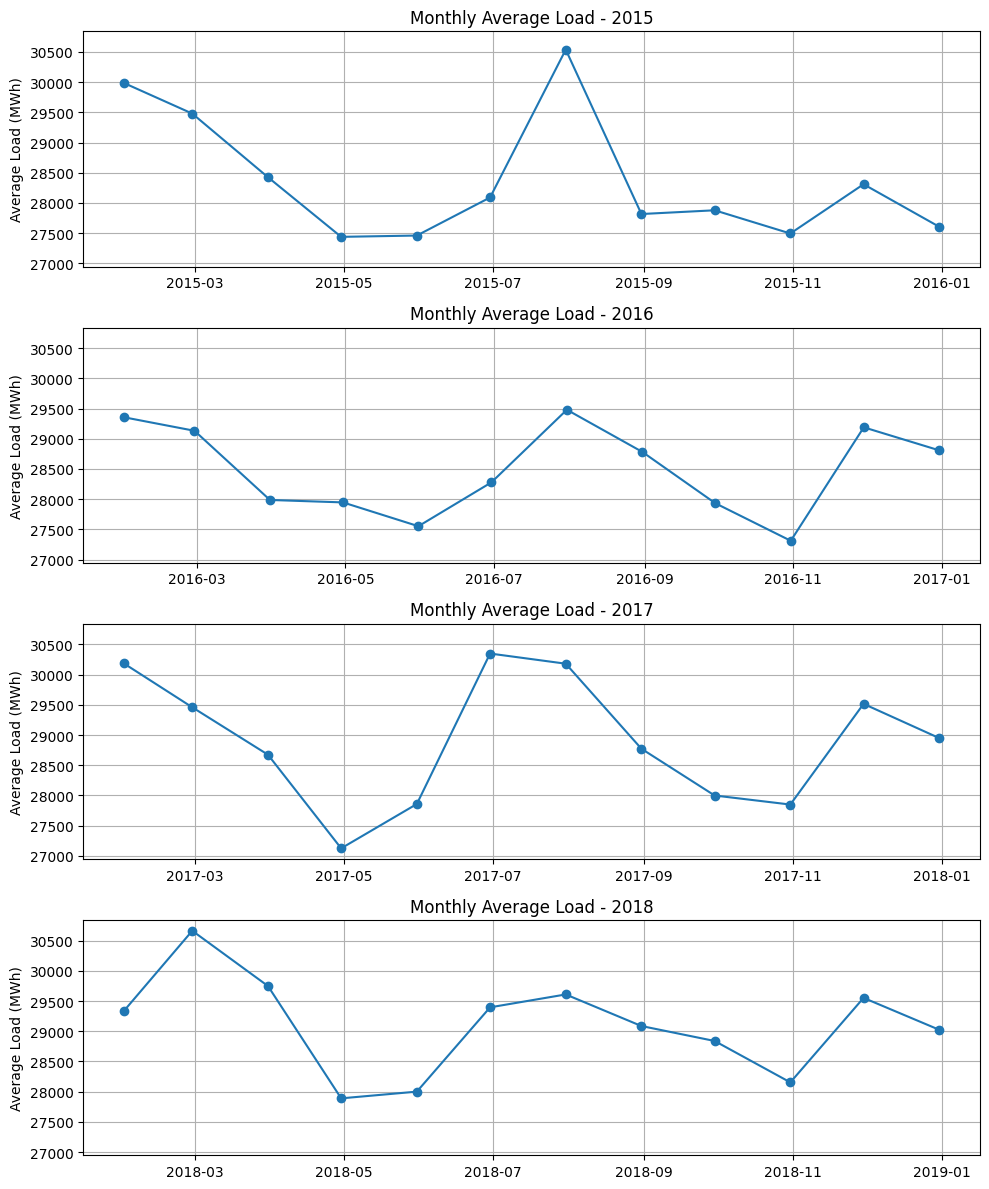

In [ ]:
# Код генерації графіка за різним рівнем resample (наприклад, щомісяця за всі роки)

##Boxplot / Violin: як змінюється навантаження та ціни за днями тижня

Візуалізуємо розподіл ознаки за днями тижня

In [ ]:
# Код побудови діаграм sns.boxplot та sns.violinplot

##Теплова мапа

Для цих даних дозволяє визначити значення параметру у просторі двох інших ознак.

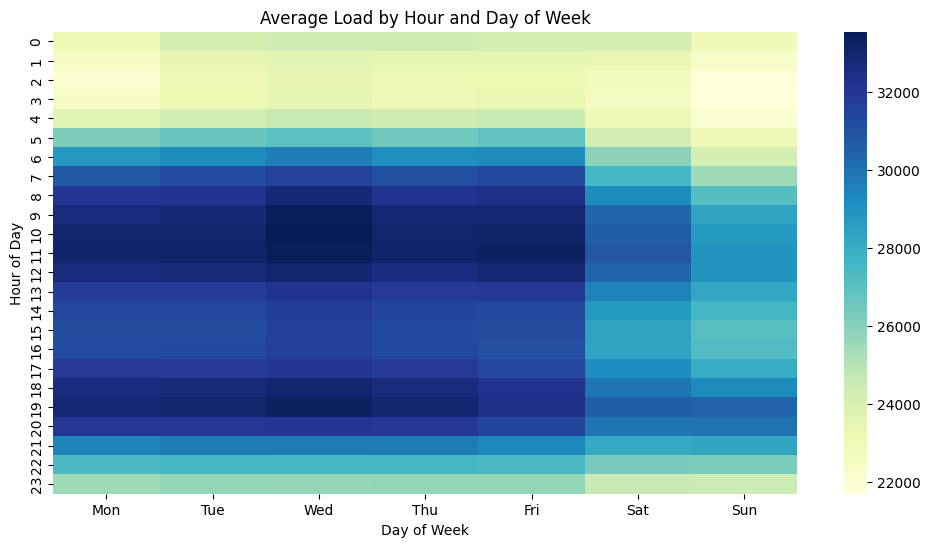

In [ ]:
# Код створення теплової мапи

## Розподіли (гістограма + KDE) для ключових числових ознак

Will plot: ['total load actual', 'price actual', 'price day ahead']


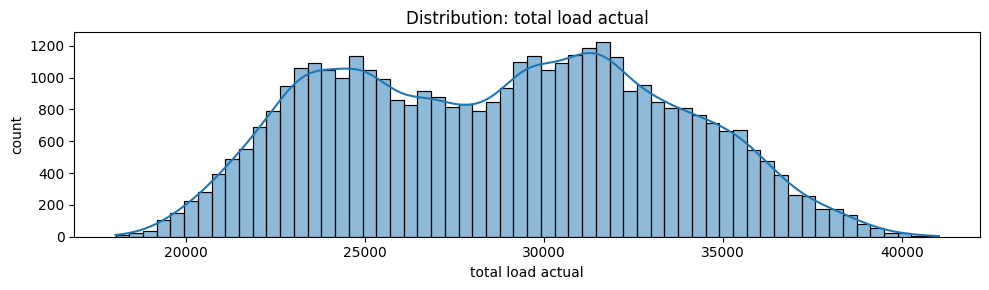

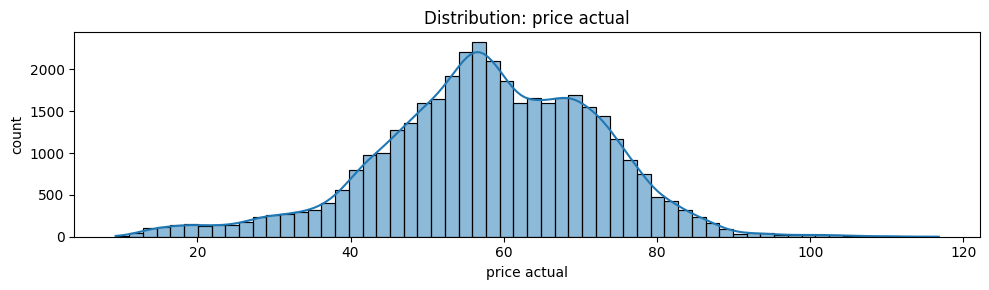

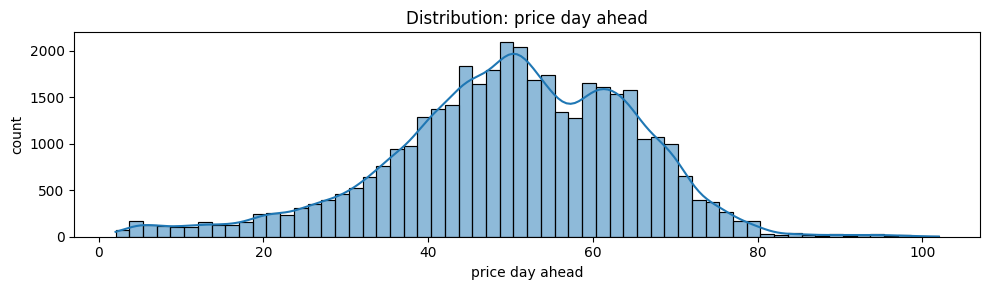

In [ ]:
# Код створення гістограм

## Добова сезонність: середні профілі по годинах (hour-of-day)

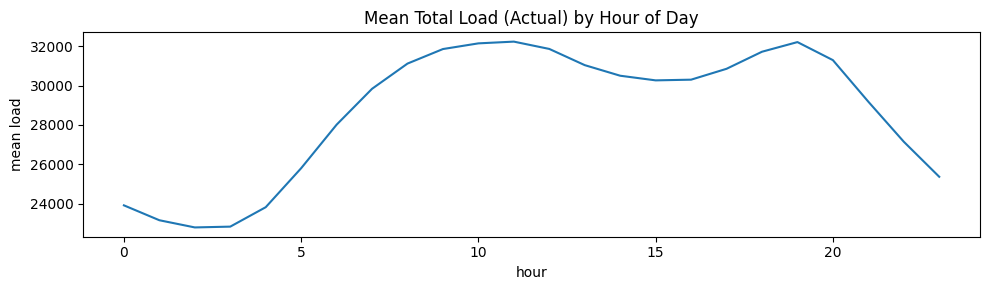

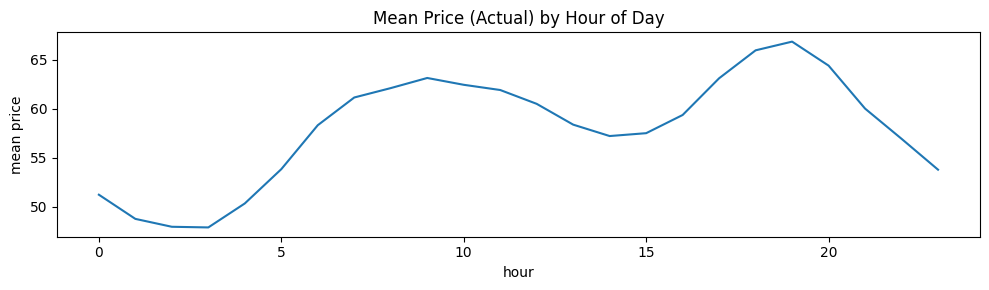

In [ ]:
# Код створення графіків

## Часові ряди: load та price у часі + згладжування (rolling mean)

Згладжування допомагає побачити тренди та зміну режимів без високочастотного шуму.

In [ ]:
df_final = df_final.reset_index()


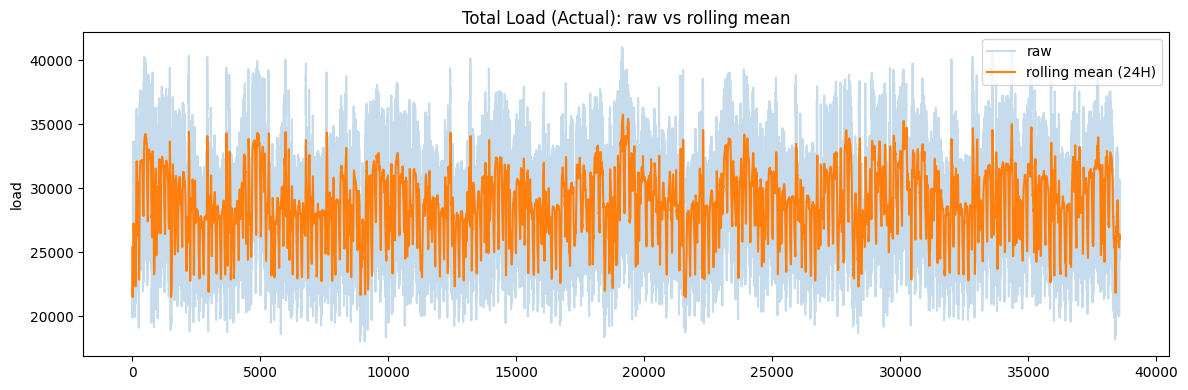

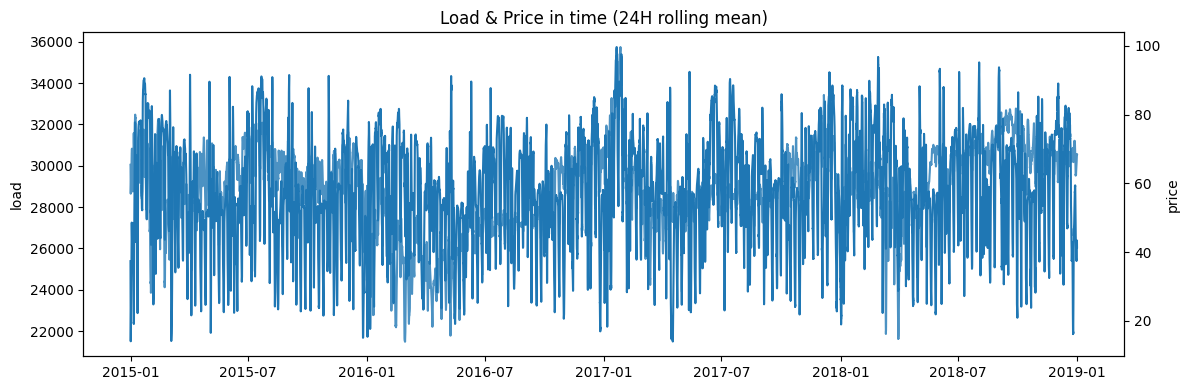

In [ ]:
# Код створення графіків

## Scatter: зв'язок load ↔ price (підвибірка)

Це базова перевірка гіпотези: з ростом навантаження ціна часто зростає.

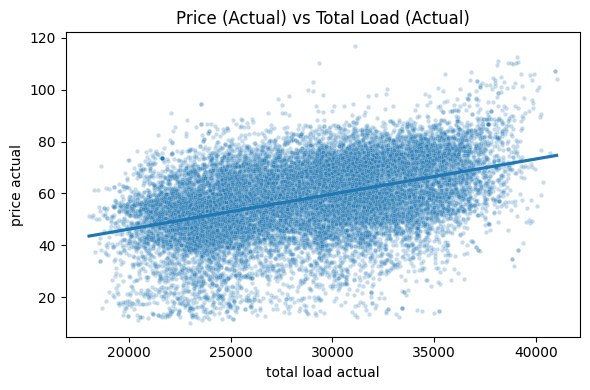

In [ ]:
# Код оцінки можливості побудови лінійної моделі прогнозування

## Погода: температура по містах (переведемо в °C) + порівняння розподілів

Температури в наборі — в **Кельвінах**, тому перетворюємо: `°C = K - 273.15`.

In [ ]:
# Код перетворення в градуси Цельсія

## Load ↔ temperature: залежність навантаження від середньої температури (по 5 містах)

Для відображення агрегуємо погоду у **середню температуру** по містах.

In [ ]:
# Код візуалізації залежності "total load actual" від "temp_mean_C"

Графік показує загалом **слабко позитивну** залежність між середньою температурою та фактичним навантаженням: зі зростанням `temp_mean_C` середній рівень `total load actual` дещо підвищується, що може відповідати зростанню споживання на кондиціювання в теплі періоди. Водночас хмара точок дуже розсіяна, тобто температура пояснює лише частину варіації попиту — суттєво впливають також добова/тижнева сезонність, структура споживання (будні/вихідні), економічна активність і інші погодні фактори. Це означає, що температуру доцільно використовувати як важливу, але **не єдину** ознаку, бажано разом із сезонними змінними та, за можливості, з нелінійними ефектами (наприклад, окремо для холодних і спекотних режимів).


# **Генерація ознак**

**Вступ.** Після EDA ми розуміємо базову поведінку рядів і можемо переходити до **інженерії ознак**: перетворити часові ряди на компактний набір числових характеристик, які описують стан енергетичної системи.

**Мета** — побудувати **feature table** для часових рядів.

**План**
1. Генерація ознак.
2. Тестування та візуалізація нових ознак.
3. Формування фінального датафрейма ознак для подальших етапів (EDA ознак / моделі).

**Результат:** датафрейм з ознаками та індикаторами, готовий для наступних аналітичних кроків або навчання моделей.


У часових рядах енергетики важливо не лише “сирі” значення, а й **похідні характеристики**, які описують:
- **динаміку** (зміни, темп зростання/спаду),
- **співвідношення** (частки генерації різних типів, відносні показники),
- **режими** (пікові години, відхилення від локальної норми),
- **зовнішні фактори** (узагальнені погодні показники по містах).

Нижче сформуємо 5 інтерпретованих ознак:
1) `price_spread` — різниця між фактичною ціною та прогнозом day-ahead  
2) `price_spread_pct` — відносна різниця (у %)  
3) `load_ramp_1h` — зміна навантаження за 1 годину (ramp)  
4) `load_roll_z_24h` — z-score навантаження відносно ковзного 24h вікна  
5) `renewable_share` — частка “зеленої” генерації в сумарній генерації

Після генерації — побудуємо візуалізації, щоб перевірити розподіли та зв’язок з цільовими величинами.

In [ ]:
import numpy as np
import pandas as pd

# Працюємо з очищеним датафреймом
df_fe = df_final.copy()

# Переконаємося, що є time як datetime і дані відсортовані
df_fe = df_fe.sort_values("time").reset_index(drop=True)


### `price_spread`

`price_spread = price actual − price day ahead`

Показує, наскільки фактична розрахункова ціна на ринку відрізняється від прогнозної (day-ahead). Додатне значення означає, що реальна ціна виявилась вищою за прогноз; від’ємне — нижчою.

Це проста, але інформативна ознака “помилки прогнозу ринку”, яка часто пов’язана з непередбачуваними подіями: різкими змінами попиту, генерації, обмеженнями мережі тощо.

In [ ]:
# Price spread - код обчислення нової ознаки


### `load_ramp_1h`

`load_ramp_1h = total load actual(t) − total load actual(t−1h)`

Описує **швидкість зміни навантаження** за одну годину (ramp). Великі за модулем значення відповідають різким переходам між режимами споживання (наприклад, ранковий/вечірній пік).

Ramp-ознаки важливі для енергосистем, оскільки швидке зростання попиту потребує маневрових потужностей і може впливати на ціну. Також це індикатор “динамічності” ряду.

In [ ]:
# Load ramp (1 hour difference) - код обчислення нової ознаки



### `load_roll_z_24h`

`load_roll_z_24h = (load − rolling_mean_24h(load)) / rolling_std_24h(load)`

Це **стандартизоване відхилення** навантаження відносно локальної (добової) “норми”. Значення близькі до 0 означають типовий режим; великі додатні/від’ємні значення сигналізують про нетипово високе/низьке навантаження для поточного контексту.

Ознака добре підходить для виявлення аномалій і режимних змін, бо враховує локальну сезонність і масштабується відносно поточної мінливості ряду.

In [ ]:
# Rolling z-score (24 hours) - код обчислення нової ознаки
# rolling mean/std по часовій сітці: простий підхід через window=24 (якщо дані погодинні без пропусків)


In [ ]:
# Renewable share
# Визначимо кошикк джерел відновлювальною енергії
renew_cols = [
    "generation solar",
    "generation wind onshore",
    "generation hydro water reservoir",
    "generation hydro pumped storage consumption",
    "generation hydro run-of-river and poundage",
    "generation other renewable",
]
renew_cols = [c for c in renew_cols if c in df_fe.columns]


### `renewable_share`

`renewable_share = generation_renewable / generation_total`

де `generation_renewable` — сума колонок із `renew_cols`, а `generation_total` — сума всіх колонок `generation ...`.

Показує **частку відновлюваних джерел** у загальній генерації в кожну годину (значення від 0 до 1).

Це структурна ознака енергобалансу. Частка ВДЕ може впливати на ринкову ціну та режим роботи системи (наприклад, за високої вітрової/сонячної генерації зростає варіативність і змінюється потреба в резерві).

In [ ]:
# Total generation: усі колонки generation - код обчислення нової ознаки


In [ ]:
# Підсумок нових ознак - статистики колонок


,count,mean,std,min,25%,50%,75%,max
price_spread,38568.0,7.976160,10.705970,-61.040000,5.310000,7.350000,10.560000,77.580000
price_spread_pct,38568.0,26.905320,81.637429,-81.386667,9.018541,14.559954,24.696080,2065.217391
load_ramp_1h,38509.0,-0.757719,1362.268356,-13187.000000,-692.000000,-8.000000,610.000000,13911.000000
load_roll_z_24h,38485.0,0.002714,1.165028,-4.694855,-0.979483,0.288402,0.849179,4.447224
renewable_share,38550.0,0.304069,0.152347,0.000000,0.185581,0.277992,0.403651,0.777237


## Розподіли нових ознак

Гістограми допомагають зрозуміти:
- чи є сильна асиметрія та “важкі хвости”,
- чи потрібне перетворення (log / clipping / robust scaling),
- чи є багато екстремальних значень.

In [ ]:
# Код гістограм розподілів

## Як price_spread змінюється за годинами доби

Це дозволяє побачити, чи є систематичні відхилення прогнозної ціни від фактичної:
- наприклад, у пікові години spread може бути більшим.

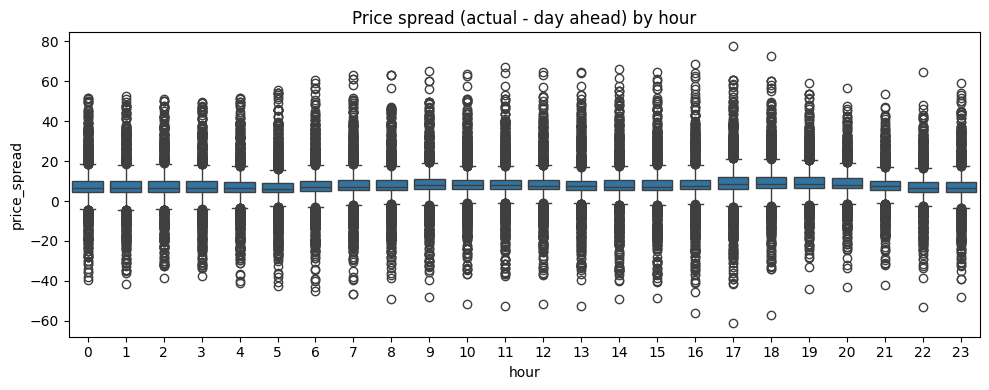

In [ ]:
# Код генерації діаграми

## Зв’язок renewable_share ↔ price actual

Інтуїтивно, при високій частці відновлюваних джерел ціна може знижуватися,
але реальний зв’язок залежить від попиту, імпорту/експорту, резервів тощо.

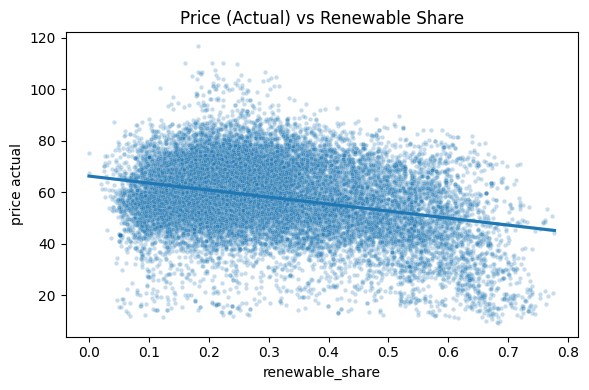

In [ ]:
# Код відображення ознак

## load_ramp_1h (ramp) та пікові “стрибки” навантаження

Ознака `load_ramp_1h` важлива для задач прогнозування, оскільки:
- великі стрибки часто відповідають зміні режиму (ранок/вечір),
- можуть корелювати з ціною та потребою в “маневреній” генерації.

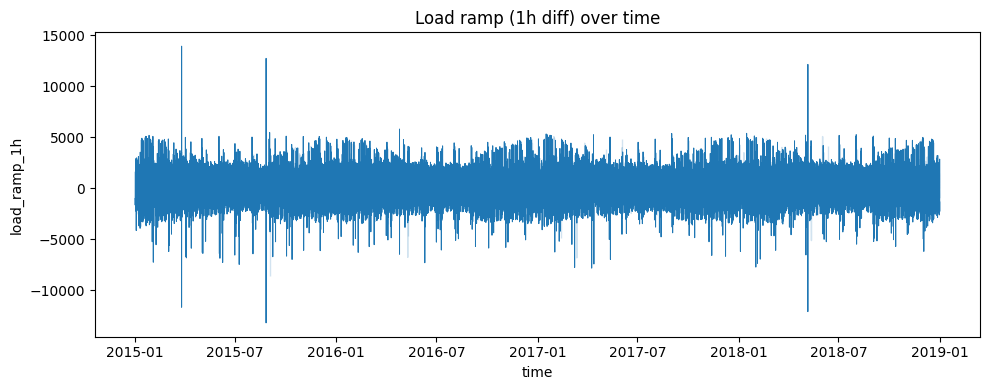

In [ ]:
# Код створення графіка

## Відхилення від локальної норми (load_roll_z_24h)

`load_roll_z_24h` — стандартизоване відхилення навантаження відносно останньої доби.
- Значення `> 2` або `< -2` часто означають аномальні режими.
- Ця ознака добре працює для моделей як “індикатор нетипових станів”.

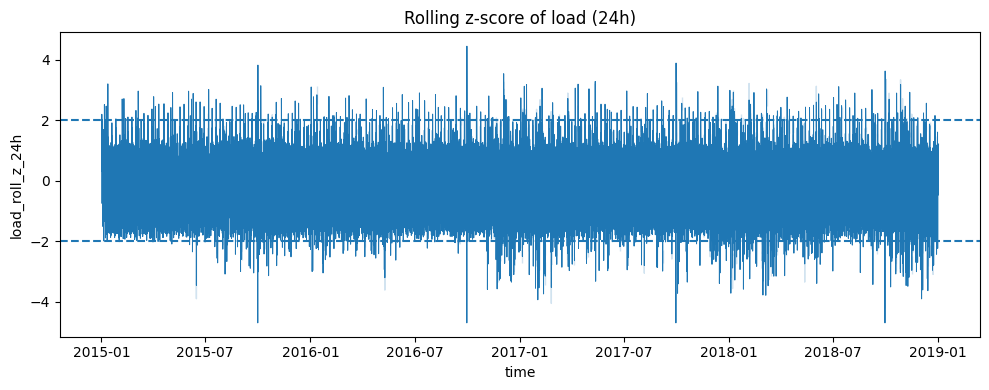

In [ ]:
# Код створення графіка